In [1]:
DATASET_PATH = "plantdataset"

In [2]:
train_path = DATASET_PATH + "/Train"
val_path   = DATASET_PATH + "/Validation"
test_path  = DATASET_PATH + "/Test"

In [3]:
import os
print(os.listdir(train_path))

['Healthy', 'Powdery', 'Rust']


In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(rescale=1./255)
val_gen   = ImageDataGenerator(rescale=1./255)
test_gen  = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_gen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1322 images belonging to 3 classes.
Found 60 images belonging to 3 classes.
Found 150 images belonging to 3 classes.


In [5]:
print(train_data.class_indices)

{'Healthy': 0, 'Powdery': 1, 'Rust': 2}


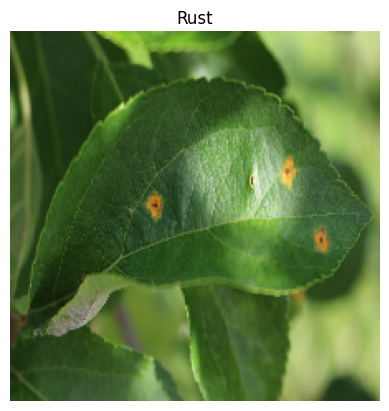

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from training data
images, labels = next(train_data)

# Convert one-hot label to class index
label_index = np.argmax(labels[0])

# Get class name
class_names = list(train_data.class_indices.keys())
label_name = class_names[label_index]

# Show image
plt.imshow(images[0])
plt.title(label_name)
plt.axis('off')
plt.show()

In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load pretrained model
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base layers
base_model.trainable = False

# Custom layers
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
EPOCHS = 10

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 182s 4s/step - accuracy: 0.8548 - loss: 0.3689 - val_accuracy: 0.9500 - val_loss: 0.1239
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 149s 4s/step - accuracy: 0.9599 - loss: 0.1175 - val_accuracy: 0.9667 - val_loss: 0.1051
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 150s 4s/step - accuracy: 0.9705 - loss: 0.0949 - val_accuracy: 0.9500 - val_loss: 0.0972
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 146s 3s/step - accuracy: 0.9773 - loss: 0.0748 - val_accuracy: 0.9500 - val_loss: 0.0953
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 144s 3s/step - accuracy: 0.9856 - loss: 0.0545 - val_accuracy: 0.9500 - val_loss: 0.0847
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 205s 4s/step - accuracy: 0.9924 - loss: 0.0384 - val_accuracy: 0.9500 - val_loss: 0.0837
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 148s 4s/step - accuracy: 0.9871 - loss: 0.0359 - val_accuracy: 0.9500 - val_loss: 0.0916
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 203s 4s/step - accuracy: 0.9826 - loss: 0.0408 - val_accuracy: 0.9500 - v

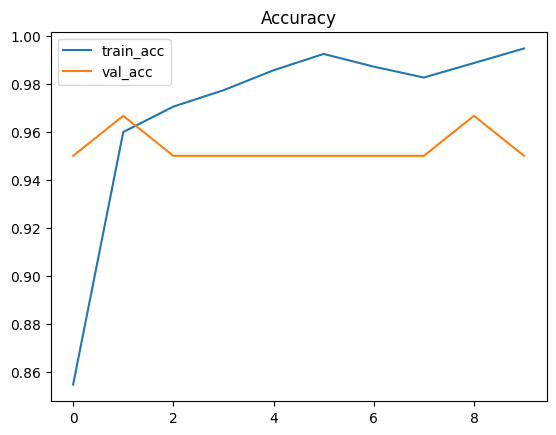

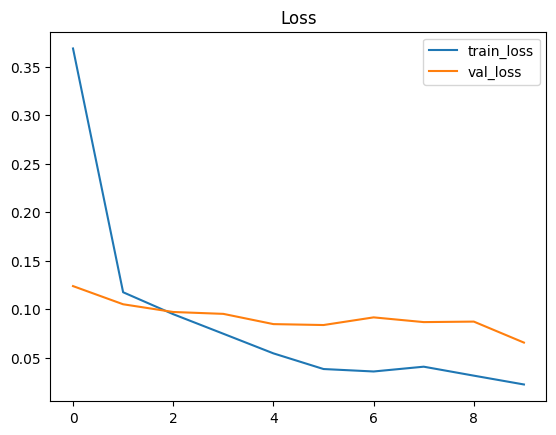

In [14]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

In [16]:
loss, acc = model.evaluate(test_data)
print("Test Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.9667 - loss: 0.1520
Test Accuracy: 0.9666666388511658


In [18]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.9947050213813782
Final Validation Accuracy: 0.949999988079071


In [20]:
model.save("plant_disease_model.h5")